# Atelier Matplotlib 

## Structure du projet

In [ ]:
# %pip install ipykernel matplotlib pandas

  Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached pandas-3.0.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached numpy-2.5.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (10.0 MB)
Using cached pand

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


## Partie 1 – Graphique linéaire (Line Plot) 

### 1) Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille. 

#### D'abord, convertis la colonne date_heure en vrai type datetime et trie le dataframe chronologiquement (sinon la courbe part dans tous les sens si les lignes ne sont pas dans l'ordre) :

In [13]:
df["date_heure"] = pd.to_datetime(df["date_heure"])
df_sorted = df.sort_values("date_heure")

#### Puis traçons le graphique :

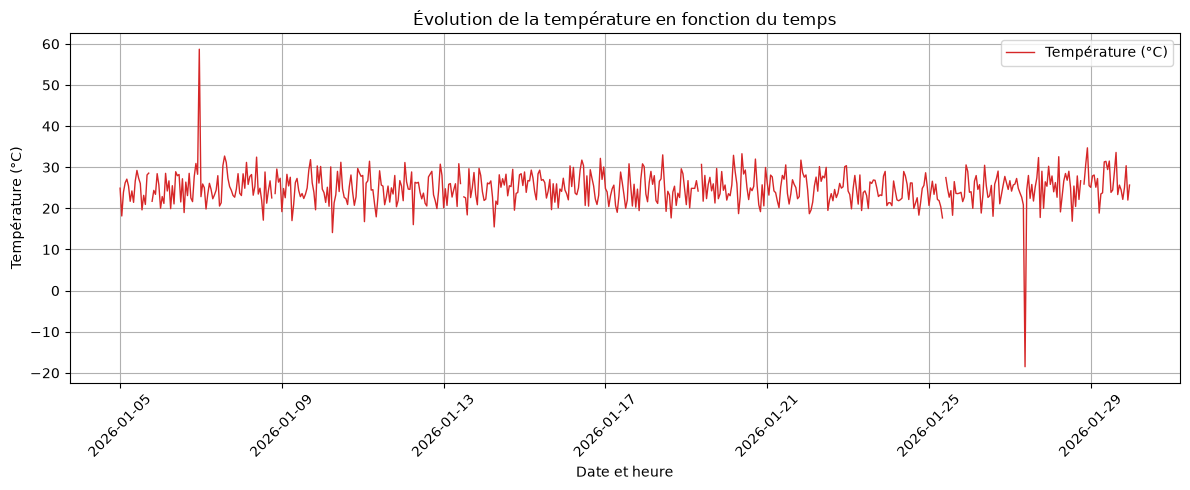

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(df_sorted["date_heure"], df_sorted["temperature"],
         color="tab:red", linewidth=1, label="Température (°C)")

plt.title("Évolution de la température en fonction du temps")
plt.xlabel("Date et heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../exports/temperature.png")
plt.savefig("../exports/temperature.pdf")
plt.show()


### 2) Identifier visuellement les valeurs qui semblent anormales. 

#### En exécutant ce code , on voit deux pics qui sortent nettement de la plage habituelle (~18-30°C) :

#### une valeur proche de -18°C, autour du 26-27 janvier
#### une valeur proche de +59°C, autour du 6-7 janvier

#### Ces valeurs isolées et très éloignées du reste des points sont probablement des erreurs de capteur plutôt que de vraies variations physiques.

## Partie 2 – Diagramme en barres (Bar Chart) 

### 1) Déterminer consommation_batiment qui stocke les consommations moyennes des bâtiments 

#### On regroupe les données par bâtiment et on calcule la moyenne de la consommation :

In [15]:
consommation_batiment = df.groupby("batiment")["consommation"].mean()
consommation_batiment

batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64

### 2) Comparer graphiquement la consommation moyenne des bâtiments 

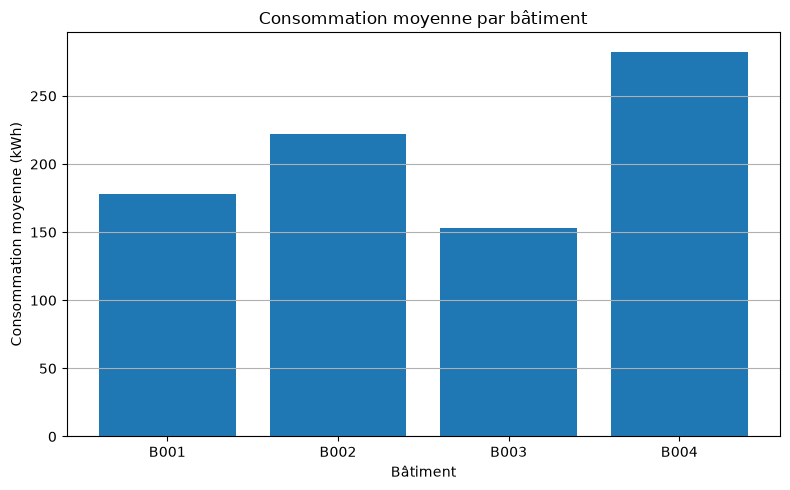

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(consommation_batiment.index, consommation_batiment.values, color="tab:blue")

plt.title("Consommation moyenne par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Consommation moyenne (kWh)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### 3) Comparer la consommation moyenne des bâtiments avec un graphique horizontal 

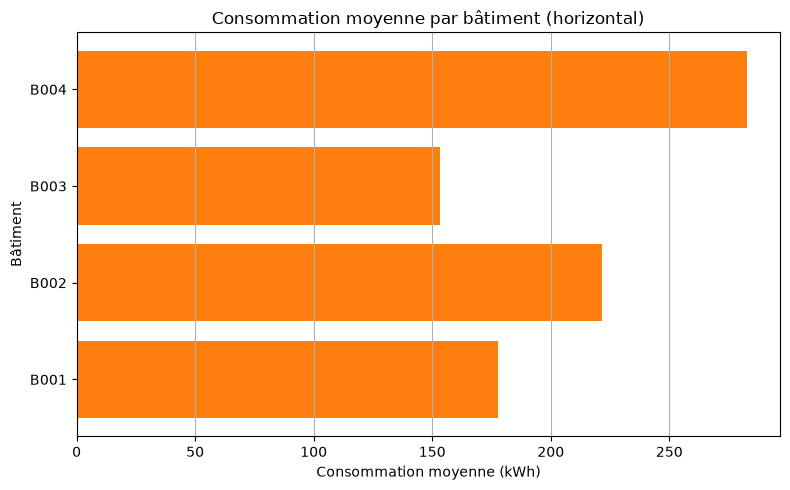

In [11]:
plt.figure(figsize=(8, 5))
plt.barh(consommation_batiment.index, consommation_batiment.values, color="tab:orange")

plt.title("Consommation moyenne par bâtiment (horizontal)")
plt.xlabel("Consommation moyenne (kWh)")
plt.ylabel("Bâtiment")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

### 4) Dans quels cas un graphique horizontal peut-il être plus lisible ? 

#### Quand les noms des catégories sont longs (ex: noms de bâtiments détaillés, intitulés de produits) — ils s'affichent horizontalement sans se chevaucher ni devoir être pivotés.
#### Quand il y a beaucoup de catégories — plus facile à lire en liste verticale qu'en barres serrées côte à côte.
#### Pour des classements (top 10, ranking) — l'œil lit naturellement de haut en bas, donc un ordre décroissant en barres horizontales se lit comme une liste triée. 

## Partie 3 – Histogramme

### 1) Afficher la distribution des températures en divisant la plage des données en 20 classes et en affichant uniquement les lignes horizontales de la grille 

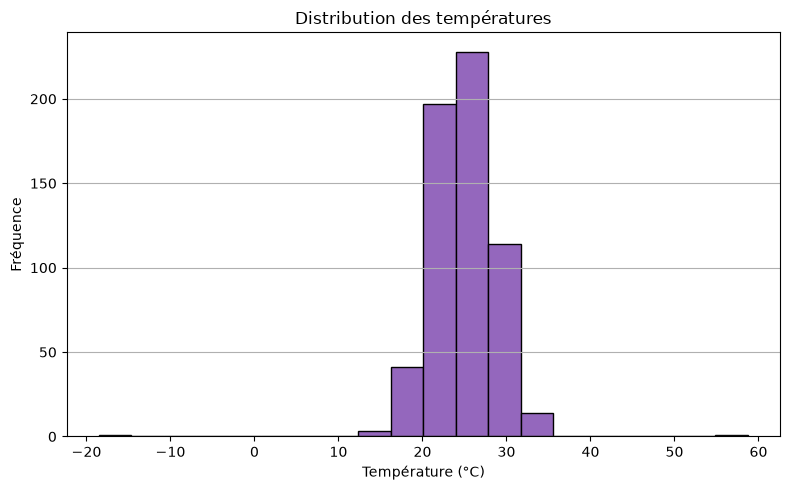

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["temperature"].dropna(), bins=20, color="tab:purple", edgecolor="black")

plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### 2) Analyser le graphique pour voir 1/2 

### a) où se concentrent les températures ;  

##### La grande majorité des mesures se situe entre 15°C et 35°C, avec un pic net autour de 20-27°C.

### b) si la distribution semble symétrique ;  

##### Globalement oui, la forme "en cloche" autour de 20-30°C est assez régulière des deux côtés. Cependant, la présence isolée de la valeur extrême à -18,5°C tire légèrement la distribution vers la gauche (asymétrie négative), ce qui casse une symétrie parfaite. Sans cette valeur aberrante, la distribution serait quasiment symétrique.

### c) s'il existe des valeurs très éloignées ;  

##### Oui, deux valeurs se détachent nettement du groupe principal : une à -18,5°C et une à 58,7°C. Ce sont des barres isolées, très basses (une seule mesure chacune), largement séparées du pic central.

### d) si des valeurs aberrantes sont visibles. 

##### Oui, ce sont les deux mêmes valeurs (~-18°C et ~59°C). Elles sont nettement séparées du groupe principal de barres, ce qui les rend visuellement aberrantes — cohérent avec les anomalies déjà repérées sur le graphique linéaire de la Partie 1.

### 3) Afficher la distribution de la consommation en divisant la plage des données en 20 classes 

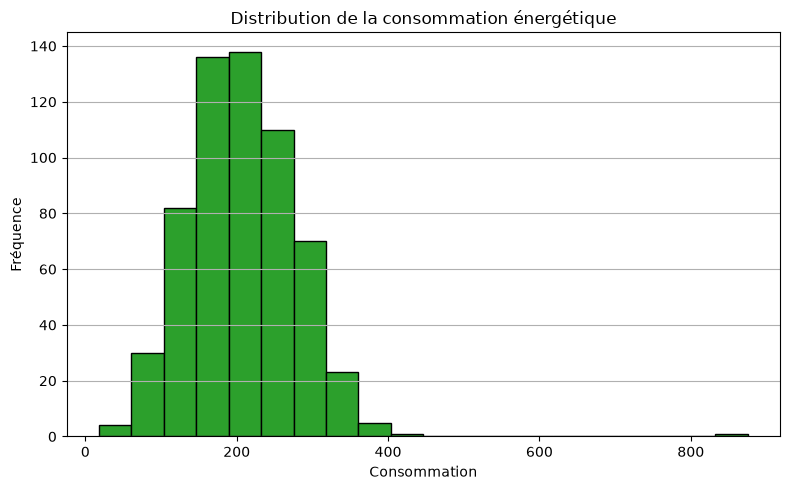

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"].dropna(), bins=20, color="tab:green", edgecolor="black")
plt.title("Distribution de la consommation énergétique")
plt.xlabel("Consommation")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### a) Modifier le nombre de classes à 10 

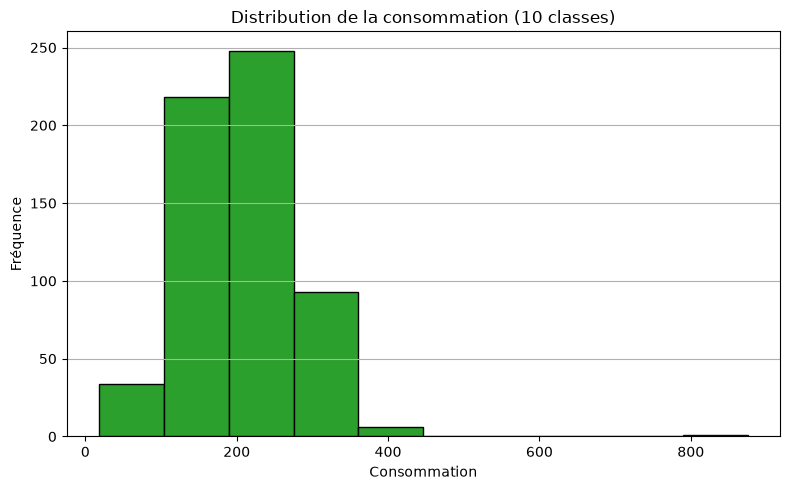

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"].dropna(), bins=10, color="tab:green", edgecolor="black")
plt.title("Distribution de la consommation (10 classes)")
plt.xlabel("Consommation")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### b) Modifier le nombre de classes à 30 

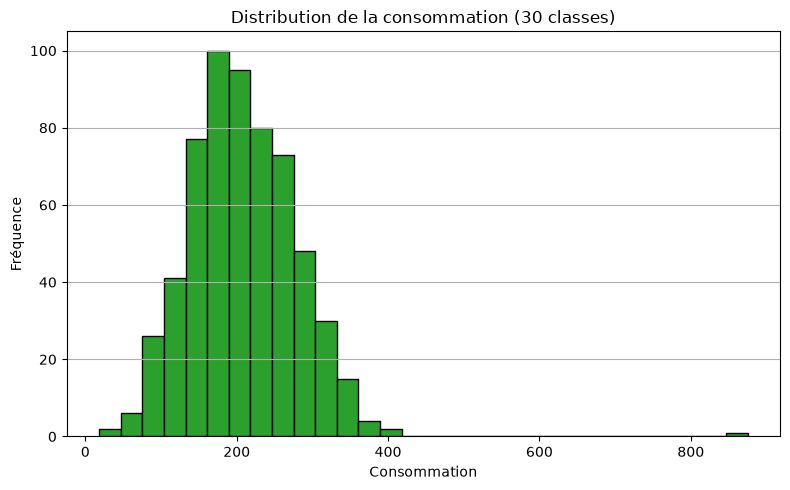

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"].dropna(), bins=30, color="tab:green", edgecolor="black")
plt.title("Distribution de la consommation (30 classes)")
plt.xlabel("Consommation")
plt.ylabel("Fréquence")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### c) Quel impact le nombre de classes a-t-il sur l'interprétation ? 

##### Avec seulement 10 classes, l'histogramme devient plus lisse et donne une vue d'ensemble simple de la distribution, mais on perd en précision : certaines variations ou petites anomalies peuvent passer inaperçues, noyées dans des barres trop larges.

##### Avec 30 classes, on gagne en détail — on distingue mieux les nuances dans la répartition des valeurs — mais le graphique devient plus irrégulier, avec des barres en dents de scie et certaines presque vides, ce qui rend la tendance générale moins facile à lire d'un coup d'œil.

##### Au final, le nombre de classes est un vrai compromis entre lisibilité et précision : trop peu de classes cache l'information, trop de classes la noie dans du bruit visuel. Avec 20 classes, on garde un bon équilibre entre une vue d'ensemble claire et un niveau de détail suffisant pour repérer d'éventuelles anomalies.

## Partie 4 – Nuage de points (Scatter Plot)

### 1) Réaliser un nuage de points entre température et consommation 

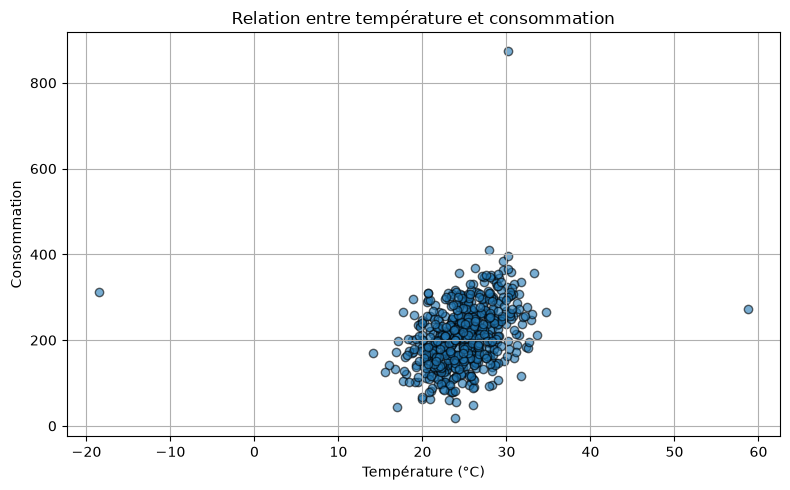

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(df["temperature"], df["consommation"], color="tab:blue", alpha=0.6, edgecolor="black")
plt.title("Relation entre température et consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.grid(True)
plt.tight_layout()
plt.show()

### 2) Déterminer visuellement s'il semble exister une relation entre les deux 

##### En regardant le nuage de points, on ne distingue pas de tendance claire : les points forment plutôt un bloc compact, sans direction diagonale montante ou descendante. Ils sont simplement regroupés ensemble, un peu partout dans la même zone.

##### Cela laisse penser qu'il n'y a pas de vraie relation entre la température et la consommation énergétique dans ce dataset. La consommation ne semble pas augmenter ou diminuer selon la température. Elle dépend probablement d'autres facteurs, comme l'usage des équipements, l'occupation du bâtiment ou les horaires d'activité, plutôt que de la température ambiante mesurée.

## Partie 5 – Diagramme à moustache (Box plot) 

### 1) Créer un box plot de la température. N’oublier pas de supprimer les valeurs manquantes avant de construire le graphique et afficher uniquement les lignes horizontales de la grille 

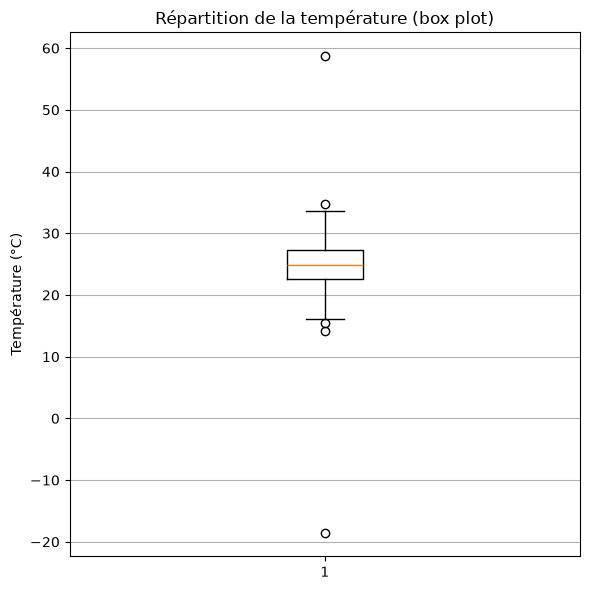

In [20]:
plt.figure(figsize=(6, 6))
plt.boxplot(df["temperature"].dropna())
plt.title("Répartition de la température (box plot)")
plt.ylabel("Température (°C)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### 2) Que représentent les points situés en dehors des moustaches ? 

#### Sur un box plot, la "boîte" représente là où se trouve la majorité des mesures normales, et les "moustaches" (les traits qui dépassent de chaque côté) représentent les valeurs encore acceptables, un peu plus hautes ou plus basses que la moyenne, mais sans être choquantes.

#### Les points isolés qu'on voit en dehors de ces moustaches sont des mesures anormalement extrêmes — des valeurs beaucoup trop hautes ou trop basses par rapport à tout le reste du groupe. On les appelle des valeurs aberrantes.

#### Dans notre cas, ces points correspondent probablement aux deux capteurs défaillants déjà repérés dans les graphiques précédents : une température d'environ -18°C (beaucoup trop froide) et une autre d'environ 59°C (beaucoup trop chaude), alors que les températures normales tournent plutôt autour de 20-30°C. Ce sont sûrement des erreurs de mesure, pas de vraies variations de température.

### 3) Créer un box plot de la consommation 

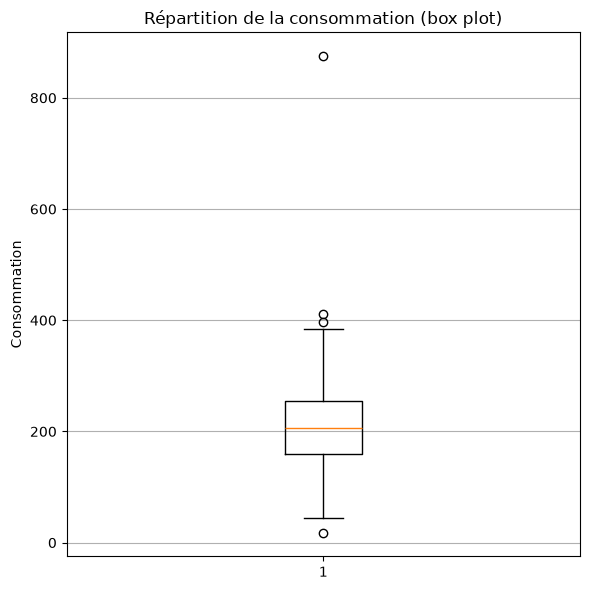

In [22]:
plt.figure(figsize=(6, 6))
plt.boxplot(df["consommation"].dropna())
plt.title("Répartition de la consommation (box plot)")
plt.ylabel("Consommation")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### 4) A partir des deux box plot, comparer : 

### a) la position de la médiane ;  

#### Sur le graphique de la température, la boîte est centrée au milieu de l'étendue totale des valeurs, et la médiane est bien centrée à l'intérieur de la boîte → distribution équilibrée.

#### Sur le graphique de la consommation, la boîte apparaît nettement plus proche du bas du graphique. Ce n'est pas que les valeurs soient "basses" en soi, mais une valeur aberrante très haute étire l'échelle du graphique vers le haut, ce qui repousse visuellement la boîte (où sont regroupées la majorité des vraies mesures) vers le bas de l'image.

### b) la taille de la boîte ;  

#### La boîte de la consommation paraît plus grande (plus haute) que celle de la température. Une boîte plus grande signifie que les valeurs "du milieu" (ni trop hautes, ni trop basses) sont plus étalées entre elles.

### c) la longueur des moustaches ;  

#### Les moustaches de la consommation semblent également plus longues que celles de la température, confirmant que même en dehors de la boîte centrale, les valeurs de consommation s'étendent sur une plage plus large.

### d) les valeurs extrêmes.  

#### Sur les deux graphiques, on voit un point isolé en haut et un point isolé en bas, en dehors des moustaches; ce sont les valeurs aberrantes (erreurs de capteurs) déjà repérées dans les parties précédentes. Le point aberrant haut de la consommation est particulièrement éloigné du reste des données, plus marquant que les autres.

### 5) La consommation présente-t-elle davantage de dispersion que la température ?

#### Oui. En reprenant ce qu'on vient d'observer aux points b) et c) :

#### La boîte de la consommation est plus grande que celle de la température → les valeurs "normales" (au centre) sont plus étalées.
#### Les moustaches de la consommation sont plus longues → même les valeurs en dehors de la boîte centrale s'étendent sur une plage plus large.
#### La consommation a aussi une valeur aberrante extrême bien plus éloignée du reste que les valeurs aberrantes de la température.

## Partie 6 – Diagramme circulaire (Pie Chart) 

### 1) Réaliser un diagramme pour analyser la répartition des états (OK, ALERTE, ERREUR) 

#### D'abord, on compte combien de fois chaque état apparaît :

In [23]:
repartition_etats = df["etat"].value_counts()
repartition_etats

etat
OK        567
ALERTE     29
ERREUR      5
Name: count, dtype: int64

#### Puis on trace le diagramme circulaire :

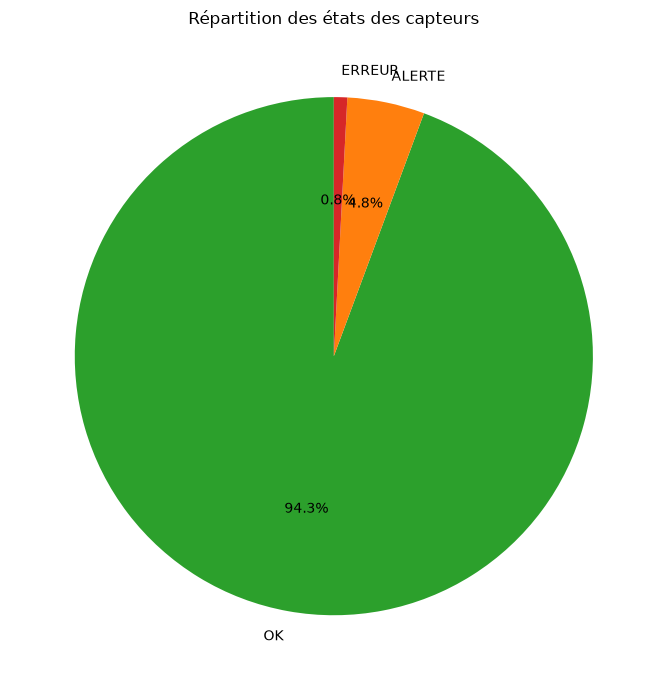

In [24]:
plt.figure(figsize=(7, 7))
plt.pie(repartition_etats.values,
        labels=repartition_etats.index,
        autopct="%1.1f%%",
        colors=["tab:green", "tab:orange", "tab:red"],
        startangle=90)

plt.title("Répartition des états des capteurs")
plt.tight_layout()
plt.show()

### 2) interpréter la proportion de capteurs OK ; proportion ALERTE ;  proportion ERREUR  

#### La très grande majorité des capteurs sont en état OK (94,3%), ce qui indique que le réseau de capteurs fonctionne correctement dans l'ensemble. Une petite part est en état ALERTE (4,8%), signalant des capteurs à surveiller sans être défaillants. Enfin, une infime minorité est en état ERREUR (0,8%, soit seulement 5 mesures) — ce nombre très faible mais non nul correspond probablement aux capteurs à l'origine des valeurs aberrantes observées dans les parties précédentes (température à -18°C ou 59°C, par exemple).